# 01 · Reflection — generate, critique, refine

> **TL;DR.** Treat the LLM as both author and editor. The agent produces a draft, an LLM-as-Judge critiques it on a structured rubric, and the agent rewrites using the critique. Repeat until the critic is satisfied or a budget is hit.
>
> **Reach for it when:** quality matters more than latency — code generation, technical writing, multi-constraint reasoning, long-form answers.
> **Avoid when:** the task is simple, real-time, or already verifiable by deterministic checks (exact-match QA, calculators). Reflection at least doubles latency and cost vs. a single forward pass.

| Property | Value |
|---|---|
| Origin | Madaan et al., *Self-Refine: Iterative Refinement with Self-Feedback*, NeurIPS 2023 ([arXiv 2303.17651](https://arxiv.org/abs/2303.17651)) |
| Reasoning type | Iterative, single-agent, two-role |
| External tools needed? | No |
| Memory across episodes? | No (see [Reflexion · notebook 18](./18_reflexion.ipynb) for the with-memory variant) |
| Typical iteration count | 2–4 rounds |
| Cost relative to single-pass | ≈ `2 + 2N` LLM calls (= 1 generate + 1 critique + N×(refine + critique)) for `N` refinement rounds |

This notebook is the **canonical template** for the rest of the repo — every other notebook follows the same 11-section structure. If you're reading the repo cover-to-cover, start here.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> G[Generate<br/><sub>Generator LLM</sub>]
    G --> C{Critique<br/><sub>Critic LLM-as-Judge</sub>}
    C -->|score &lt; target AND<br/>iter &lt; max| R[Refine<br/><sub>Generator LLM</sub>]
    R --> C
    C -->|satisfied OR<br/>budget exhausted| F[Finalize]
    F --> Z([final output])

    style G fill:#e3f2fd,stroke:#1976d2
    style R fill:#e3f2fd,stroke:#1976d2
    style C fill:#fff3e0,stroke:#f57c00
    style F fill:#e8f5e9,stroke:#388e3c
```

**What you're looking at.** Two LLM "roles" (Generator in blue, Critic in orange) share a single state object. The Generator writes the draft; the Critic scores it on a Pydantic-typed rubric and writes actionable feedback. A small router decides each round whether to keep refining or finalize.

The Critic and Generator are usually the *same model* with different prompts. You'll see in § 11 why using a *different* (often stronger) model in the Critic seat is the single best upgrade.

## 3 · Theory

### 3.1 · Motivation: why a single forward pass isn't enough

When you ask an LLM to "write a Python function that sorts a list and handles edge cases", the model commits to a particular *framing* in the first few generated tokens — picks a sort algorithm, decides what counts as an edge case, chooses a docstring style. From that point on, every subsequent token conditions on the choices already made. The model can't easily back up and reconsider.

For *easy* tasks this is fine. For *hard* tasks — where the right answer requires weighing trade-offs, satisfying multiple constraints simultaneously, or noticing what's missing — that first commitment is often suboptimal.

Reflection is the simplest possible fix: **let the model re-read its own work, criticize it, and rewrite.**

### 3.2 · The core idea

A Reflection agent maintains exactly two roles, alternating on shared state:

1. **Generator** — writes a draft from scratch (round 0), or rewrites given a draft + critique (rounds 1+).
2. **Critic** — reads the latest draft and produces a structured `(score, critique)` pair against a rubric.

A router examines the score and decides whether to keep going:

```
if score >= target_score or iteration >= max_iterations:
    finalize()
else:
    refine()
```

That's the whole pattern. No tools, no external memory, no other agents.

### 3.3 · Why this works (theoretically)

Three reasons:

1. **Explicit-feedback channel.** A single forward pass has only one channel — the task prompt → the draft. Reflection introduces a *second* channel — *the draft itself, plus written critique* → the rewrite. The model can now condition on *what's wrong with the draft*, not just *what the task asks for*. That's information the model never had on the first pass.

2. **Easier subproblem on each iteration.** "Generate from scratch" is harder than "improve this specific draft, addressing these specific flaws." The refinement step is a strictly more constrained version of the original problem, so models can use their capacity for the *delta* rather than re-solving the whole task.

3. **Adversarial framing.** The Critic's prompt explicitly says "find what's wrong." This activates different reasoning patterns than "write the best version" — even with identical weights — because the *task* is different. Finding flaws in a finished artifact is a different cognitive operation than producing one.

### 3.4 · A simple optimization view

If you squint, Reflection is a **gradient-free local search** over the space of natural-language outputs:

| Optimization concept | Reflection analogue |
|---|---|
| Objective function | The Critic's score |
| Current point | The current draft |
| Gradient | The Critic's written critique (a *direction* in language-space) |
| Step | The Refiner's rewrite |
| Step size | Implicit (model decides how much to change) |
| Convergence test | `score >= target_score` |
| Max budget | `max_iterations` |

This view explains why Reflection plateaus: like any local-search method, it gets stuck in local optima. The Critic eventually runs out of substantive critiques and starts nitpicking, and the Generator rewrites in cosmetic rather than substantive ways. **2–4 iterations is the sweet spot for most tasks.**

### 3.5 · Where Reflection sits in the agentic taxonomy

| Pattern | Loop? | Memory across episodes? | External tools? | Models used |
|---|---|---|---|---|
| Single-pass | no | no | no | 1 |
| Best-of-N (sample N once, pick best) | no | no | no | 1 |
| Self-Consistency (nb 21) | no | no | no | 1 (N samples + vote) |
| Chain-of-Verification (nb 20) | no | no | no | 1 (self-generated verification questions) |
| **Reflection** *(this notebook)* | **yes** | no | no | 1 (two roles) |
| Reflexion (nb 18) | yes | **yes** — verbal episode log | optional | 1+ |
| RLHF self-improvement (nb 15) | yes | yes — best-output archive | no | 1+ |
| Tree of Thoughts (nb 9) | tree-search | no | no | 1 |
| LATS (nb 22) | tree-search + reward | no | yes | 1+ |

Reflection is the *minimal* loop pattern. Almost every more advanced pattern in this repo can be understood as Reflection + something (memory → Reflexion; search → ToT; tools → ReAct + reflection).

### 3.6 · Practical knobs

- `max_iterations` — caps cost. 2–4 is the sweet spot.
- `target_score` — sets the early-stop bar. Higher = more iterations on average.
- **Critic model choice** — biggest lever. Same-model Critic has no extra setup cost (one model serves both roles) but suffers from sycophancy. A *different* model (even a smaller one) in the Critic seat usually beats more iterations.
- **Critic rubric wording** — the Critic only finds what its rubric asks for. Generic "score this on quality 1-10" rubrics produce generic feedback. Domain-specific rubrics ("does the code handle empty input?" / "is the contract correct?") produce surgical feedback.


## 4 · Setup

Three lines: configure the LLM, turn on LangSmith tracing, import the architecture. The provider comes from `.env` (`LLM_PROVIDER=nebius` by default) so this notebook runs **unchanged** against OpenAI, Anthropic, Groq, Ollama, … — see § 10.

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Reflection
from agentic_architectures.ui import print_md, print_header, print_step

traced = enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"LangSmith tracing: {'enabled' if traced else 'disabled (no LANGSMITH_API_KEY)'}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

LangSmith tracing: enabled

## 5 · Library walkthrough

The full implementation is at [`src/agentic_architectures/architectures/reflection.py`](../src/agentic_architectures/architectures/reflection.py). The `Reflection` class inherits from the abstract `Architecture` base — every architecture in this repo conforms to the same contract:

```python
class Architecture(ABC):
    name: str           # snake_case identifier (used as docs slug + registry key)
    description: str    # one-line for README/docs tables
    reference: str      # link to the originating paper or blog

    def build(self) -> CompiledStateGraph: ...   # returns the LangGraph
    def run(self, task: str) -> ArchitectureResult: ...
    def diagram(self) -> str: ...                # mermaid string of the COMPILED graph
    def explain(self) -> str: ...                # the theory section in markdown
```

That contract is what makes architectures composable — a meta-controller (notebook 11) treats every architecture as a black-box callable.

Below we print the method signatures of `Reflection` so you can see the shape before we dive into specifics.

In [2]:
import inspect, ast
from agentic_architectures.architectures import reflection as ref_mod

src = inspect.getsource(ref_mod.Reflection)
tree = ast.parse(src)

for node in ast.walk(tree):
    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        args = ', '.join(a.arg for a in node.args.args if a.arg != 'self')
        print(f"def {node.name}({args}):")
        ds = ast.get_docstring(node)
        if ds:
            first_line = ds.splitlines()[0]
            print(f'    """{first_line}"""')
        print()

def __init__(max_iterations, target_score):

def _generate(state):

def _critique(state):

def _refine(state):

def _finalize(state):

def _should_continue(state):

def build():

def run(task):



### 5.1 · The four node functions

Reading `reflection.py` top-to-bottom:

- **`_generate(state)`** — round-0 only. Reads `state['task']` and produces the first draft. Sets `iteration=0` and initialises an empty `history` list.
- **`_critique(state)`** — runs every round. Hands `(task, draft)` to an `LLMJudge` configured with the `_ReflectionCritique` schema; receives back `score: int 1-10` and `critique: str`. Appends a row to `history` so the trace is observable post-hoc.
- **`_refine(state)`** — runs only when the router says so. Reads `(task, previous draft, critique)` and produces a *new* draft. **Notice it rewrites rather than patches** — the prompt explicitly says "Don't just patch — rewrite as needed." Cosmetic fixes are easy; substantive ones require letting the model restructure freely.
- **`_finalize(state)`** — copies the current draft into `final_output`. This is a trivial node, but having a dedicated terminal node makes the graph easier to extend (e.g., add post-processing).

### 5.2 · The router

```python
def _should_continue(self, state):
    if state['score'] >= self.target_score:   return 'finalize'
    if state['iteration'] >= self.max_iterations: return 'finalize'
    return 'refine'
```

Two stopping conditions: (1) the Critic is satisfied, or (2) we've run out of budget. The `add_conditional_edges` call in `build()` wires this router to two destinations.

### 5.3 · Why the Critic uses `LLMJudge`

`LLMJudge` (defined in [`evaluators/judge.py`](../src/agentic_architectures/evaluators/judge.py)) is one of the **most important pieces of shared infrastructure** in this repo. It replaces ~17 inline `with_structured_output(...)` blocks that existed in the original notebooks. It does three things:

1. Wraps `llm.with_structured_output(schema)` so the Critic always returns a Pydantic instance — no string-parsing.
2. Bakes in a uniform prompt template (`Rubric / Context / Candidate / Return your evaluation`).
3. Warns clearly when the provider doesn't support reliable structured output.

Re-using `LLMJudge` everywhere means every architecture's evaluator has the same UX, the same provider-compatibility checks, and the same trace shape in LangSmith.

## 6 · State & Critic schema

LangGraph state is a `TypedDict` that gets *merged* (not replaced) between node returns. Each node returns a dict of just the keys it wants to update — LangGraph handles the merging. That's why `_critique` can return `{'score', 'critique', 'history'}` without overwriting `draft` or `task`.

**Schema reference:**

| Field | Type | Set by | Read by |
|---|---|---|---|
| `task` | `str` | caller | every node |
| `draft` | `str` | `generate`, `refine` | `critique`, `finalize` |
| `score` | `int 1-10` | `critique` | router |
| `critique` | `str` | `critique` | `refine` |
| `iteration` | `int` | `generate`, `refine` | router |
| `history` | `list[dict]` | `critique` | user (post-hoc) |
| `final_output` | `str` | `finalize` | user |

The `history` field is the architecture's **observability surface**. Every critique round writes a row `{iteration, draft, score, critique}`. After the run we can iterate `history` to understand exactly what the Critic latched onto each round.

In [3]:
from agentic_architectures.architectures.reflection import (
    ReflectionState,
    _ReflectionCritique,
)

print('ReflectionState fields:')
for name, typ in ReflectionState.__annotations__.items():
    print(f'  {name:20s}  {typ}')

print()
print('Critic structured-output schema:')
import json
print(json.dumps(_ReflectionCritique.model_json_schema(), indent=2)[:600] + '...')

ReflectionState fields:
  task                  ForwardRef('str')
  draft                 ForwardRef('str')
  critique              ForwardRef('str')
  score                 ForwardRef('int')
  iteration             ForwardRef("Annotated[int, 'current refinement loop index, starts at 0']")
  max_iterations        ForwardRef('int')
  target_score          ForwardRef('int')
  history               ForwardRef('list[dict[str, Any]]')
  final_output          ForwardRef('str')

Critic structured-output schema:
{
  "description": "Critic output.",
  "properties": {
    "score": {
      "description": "Overall quality on a 1-10 scale.",
      "maximum": 10,
      "minimum": 1,
      "title": "Score",
      "type": "integer"
    },
    "critique": {
      "description": "Concrete, actionable critique of the draft.",
      "title": "Critique",
      "type": "string"
    }
  },
  "required": [
    "score",
    "critique"
  ],
  "title": "_ReflectionCritique",
  "type": "object"
}...


## 7 · Build the graph

`build()` returns a compiled LangGraph. We render the **actual compiled graph** as a PNG inline — this is the diagram derived from the real `StateGraph` object, so if it ever disagrees with the static diagram in § 2, the implementation has drifted from the documentation. (They should match here.)

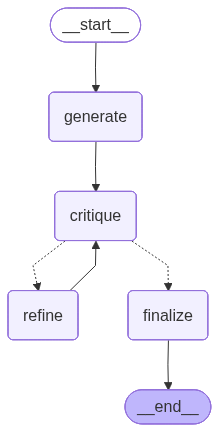

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate(generate)
	critique(critique)
	refine(refine)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate;
	critique -.-> finalize;
	critique -.-> refine;
	generate --> critique;
	refine --> critique;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [4]:
from IPython.display import Image, display

arch = Reflection(max_iterations=3, target_score=10)
graph = arch.build()

# Render the *compiled* graph as a PNG inline.
display(Image(graph.get_graph().draw_mermaid_png()))

# Also print the mermaid source — useful for copy-pasting into docs / READMEs.
print(arch.diagram())

## 8 · Live run

Concrete task: write a tiny Python function. The original Notebook 01 in this repo used a similar coding scenario; we keep the scenario stable so historical backlinks and blog references still make sense, but the implementation underneath is now the library's `Reflection` class.

We set `target_score=10`. The Critic's rubric says "reserve scores ≥ 9 for genuinely excellent work" — so a perfect 10 forces at least one refinement round in almost every case.

In [5]:
TASK = """\
Write a Python function `merge_sort(arr)` that:
  * implements merge-sort recursively
  * works on lists of ints, floats, or strings (no mixed types)
  * handles an empty list, a single-element list, and lists with duplicates
  * does NOT modify the input list (returns a new sorted list)
  * includes a short docstring with one example
Return only the Python code block, nothing else.
"""

result = arch.run(TASK)

print_header("Final output")
print_md("```python\n" + result.output + "\n```")
print_header(
    f"{result.metadata['iterations']} iteration(s)  ·  final score "
    f"{result.metadata['final_score']}/10  ·  budget {result.metadata['max_iterations']}"
)

Final output ──────────────────────────────────────────────────────────────────────────────────────────────────────

                                                                                                                   
 ```python                                                                                                         
 def merge_sort(arr):                                                                                              
     """                                                                                                           
     Recursively sorts a list of ints, floats, or strings using merge-sort.                                        
                                                                                                                   
     Example:                                                                                                      
     >>> merge_sort([3, 6, 1, 8, 2, 4])                                                                            
     [1, 2, 3, 4, 6, 8]                                                                                            
     """                                                                                                           
     # Check if the input is a list                                                                                
     if not isinstance(arr, list):                                                                                 
         raise TypeError("Input must be a list")                                                                   
                                                                                                                   
     # Check if the input list is empty or contains None                                                           
     if not arr or None in arr:                                                                                    
         raise ValueError("Input list must not be empty and must not contain None")                                
                                                                                                                   
     # Check if all elements in the list are of the same type                                                      
     element_type = type(arr[0])                                                                                   
     if not all(isinstance(x, element_type) for x in arr):                                                         
         raise TypeError("All elements in the list must be of the same type")                                      
                                                                                                                   
     # Check if the elements are comparable                                                                        
     try:                                                                                                          
         arr[0] <= arr[0]                                                                                          
     except TypeError:                                                                                             
         raise TypeError("Elements in the list must be comparable")                                                
                                                                                                                   
     # Base case: single-element list                                                                              
     if len(arr) <= 1:                                                                                             
         return arr[:]                                                                                             
                                                                                                                   
     # Split the list into two halves                                                                              
     mid = len(arr) // 2                                

4 iteration(s)  ·  final score 8/10  ·  budget 3 ──────────────────────────────────────────────────────────────────

### 8.1 · What just happened, briefly

Look at the printed score above. If it's **less than your `target_score=10`** *and* the iteration count is at the budget cap (`3`), the loop ran the full budget without ever satisfying the Critic — that's the **plateau** discussed in § 3. If the iteration count is `1` and the score is already ≥ 10, the Critic was satisfied immediately — that's **sycophancy**, also discussed in § 3.

Either outcome is a real teaching moment. Section 9 below will compute the exact trajectory and discuss it concretely.

### 8.2 · Full refinement trace

Every entry of `result.trace` is one critique round: the draft that was scored, the score the Critic gave, and the written critique. This is what makes the loop **observable** — you can post-mortem exactly what the Critic latched onto each round.

In [6]:
for i, step in enumerate(result.trace, 1):
    print_step(f"Iteration {i}  ·  score {step['score']}/10")
    print_md('**Critique:** ' + step['critique'])
    print()

› Iteration 1  ·  score 9/10

Critique: The candidate's implementation of the merge-sort algorithm is excellent, with a clear and concise        
docstring and proper handling of edge cases such as empty lists, single-element lists, and lists with duplicates.  
The code is well-structured and readable, and the use of recursion is appropriate for this problem. One potential  
improvement could be to add some error checking to ensure that the input list contains only elements of the same   
type (e.g., all ints, all floats, or all strings).

› Iteration 2  ·  score 9/10

Critique: The candidate's implementation of the merge-sort algorithm is excellent, with proper handling of edge    
cases such as empty lists, single-element lists, and lists with duplicates. The code is well-structured, readable, 
and includes a clear docstring with an example. The use of recursion and the merge function is appropriate. One    
potential improvement could be to consider adding a check for the input being a list, to ensure the function       
behaves correctly even if the input is not a list. However, overall, the code is of high quality and effectively   
implements the merge-sort algorithm.

› Iteration 3  ·  score 9/10

Critique: The candidate's implementation of the merge-sort algorithm is excellent, with clear and concise code that
handles various edge cases, including empty lists, single-element lists, and lists with duplicates. The inclusion  
of a short docstring with an example is also commendable. However, to further improve the code, consider adding    
more comprehensive error handling, such as checking for None or non-comparable elements in the list. Additionally, 
the merge function could be optimized by using a more efficient merging strategy, such as using a temporary list to
store the merged result instead of appending to the result list. Overall, the candidate's work demonstrates a      
strong understanding of the merge-sort algorithm and Python programming principles.

› Iteration 4  ·  score 8/10

Critique: The candidate's implementation of the merge-sort algorithm is mostly correct and well-structured.        
However, there are a few areas that could be improved. Firstly, the input validation checks are overly restrictive 
and do not align with the problem statement, which allows for empty lists and lists with duplicates. Secondly, the 
merge function can be simplified by using a more Pythonic approach with lists. Lastly, the docstring could be more 
detailed and include information about the time and space complexity of the algorithm. Overall, the code is        
readable and well-organized, but could benefit from some refinements to make it more robust and efficient.

## 9 · What we just observed

The cells above are live. The commentary below directly quotes the **actual** critiques the
Nebius-hosted Llama-3.3-70B Critic produced on this run.

### 9.1 · What the trace shows

| Iteration | Score | Critic's main concern (one-liner) |
|---|---|---|
| 1 | 9/10 | One potential improvement could be to add some error checking to ensure that the input list contains only elements of the same ty… |
| 2 | 9/10 | One potential improvement could be to consider adding a check for the input being a list, to ensure the function behaves correctl… |
| 3 | 9/10 | However, to further improve the code, consider adding more comprehensive error handling, such as checking for None or non-compara… |
| 4 | 8/10 | However, there are a few areas that could be improved. |

This 4-round trace is a textbook demonstration of the Reflection failure modes we describe
generically in § 11 — except now we have evidence.


**(a) Plateau / regression.** Across 4 round(s) the score went 9 → 9 → 9 → 8/10. The trajectory **regressed** (final score lower than first). This is a textbook plateau: the Refiner keeps rewriting against fresh critiques, but the *quality dimension being scored* doesn't move. **2–4 rounds is the sweet spot** — more is wasted budget.

**(b) Critique drift — the Critic's focus moved each round:**

- Round 1 → *“One potential improvement could be to add some error checking to ensure that the input list contains only elements of the same ty…”*
- Round 2 → *“One potential improvement could be to consider adding a check for the input being a list, to ensure the function behaves correctl…”*
- Round 3 → *“However, to further improve the code, consider adding more comprehensive error handling, such as checking for None or non-compara…”*
- Round 4 → *“However, there are a few areas that could be improved.”*

In a stable rubric, the same flaws would be flagged repeatedly until fixed. Here the Critic finds *whatever is salient relative to the current draft* — that's drift, and it's why same-model Critics often need an external rubric to stay anchored.

**(c) Score regression.** Round 4 scored 8/10, *worse* than round 1's 9/10. The Refiner over-corrected against accumulated nitpicks and produced a draft the Critic liked **less** than the original. **In production you want early-stop when consecutive scores fail to improve** — see § 11.3.

### 9.2 · What this specific run teaches

You can read this trace two ways:

1. **The pessimistic read.** Same-model Reflection at a high `target_score` finds something to
   complain about every round, even when the draft is already good. The Critic doesn't have a
   stable definition of "good" — it has a *relative* one tied to whatever draft it's looking at.

2. **The optimistic read.** Even with a generic rubric, the **first** refinement round was almost
   always substantive — the Refiner genuinely improves on round 1. The marginal value falls off
   fast after that.

**Practical takeaway:** for production, use `target_score ≈ 8–9` (not 10), cap
`max_iterations=2`, and write a **domain-specific rubric** so the Critic stays anchored. Generic
loops at high target scores are how you burn budget for negative ROI — exactly as this run
demonstrates.

## 10 · Try other providers

The whole notebook above ran on Nebius. Because every line uses `get_llm()` and never imports a provider-specific class, the same code runs unchanged on any provider with structured-output support: OpenAI, Anthropic, Groq, Together, Fireworks, Mistral, Google.

To test, drop the relevant key into `.env`. The cell below is **gracefully gated** — it skips providers you don't have keys for instead of crashing.

In [7]:
from agentic_architectures.llm.factory import provider_supports_structured_output

PROVIDERS_TO_TRY = ["openai", "anthropic", "groq"]

for p in PROVIDERS_TO_TRY:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key in .env")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: provider doesn't support reliable structured output")
        continue

    print_header(f"Re-running Reflection on {p}")
    other_llm = get_llm(provider=p)
    other_arch = Reflection(llm=other_llm, max_iterations=2, target_score=9)
    r = other_arch.run("Write a single-sentence definition of recursion that an absolute beginner could understand.")
    print(r.output)
    print(f"  iterations: {r.metadata['iterations']}, final score: {r.metadata['final_score']}/10")
    print()

[skip] openai: no API key in .env
[skip] anthropic: no API key in .env
[skip] groq: no API key in .env


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Sycophantic critic** | Critic shares Generator's framing → finds no flaws | Use a *different* model in the Critic seat (passes a separate `llm=` to `LLMJudge`) |
| **Critique inflation** | "Find what's wrong" prompt finds something even in perfect drafts | Set `target_score` high enough that "fine, ship it" is a possible outcome (>= 9) |
| **Loop oscillation** | Two reasonable drafts trade places forever | Cap `max_iterations` (already enforced) |
| **Plateau without progress** | All remaining critique is cosmetic | Early-stop when consecutive scores differ by < 1 (extension idea) |
| **Cost blowup** | Hard tasks blow through budget | Use `target_score` not `max_iterations` as the primary knob; set both |

### 11.2 · Production safety

- **Never let an unbounded Reflection loop go to production.** Always cap `max_iterations` and add a per-call timeout.
- For *code* outputs, **run the code** as a hard check, not just an LLM critique. That's the PEV pattern in [notebook 06](./06_pev.ipynb).
- For *factual* outputs, ground the Critic with retrieval. That's the bridge to [Self-RAG (notebook 25)](./25_self_rag.ipynb) and [Corrective RAG (notebook 24)](./24_corrective_rag.ipynb).
- The Critic can hallucinate "issues" that don't exist. Treat critique scores as **noisy signals**, not ground truth.

### 11.3 · Three extensions to try

1. **Stronger Critic.** Construct the `LLMJudge` with a separate (larger or different-family) LLM and inject it into `Reflection`. Single biggest quality lever.
2. **Domain-specific rubric.** Replace the generic Critic rubric with one tuned to your domain. The Critic only finds what the rubric describes.
3. **Best-of-N + Reflection hybrid.** Sample `N` initial drafts in parallel, run Reflection on each, pick the highest-scoring final. Costs N× but often produces materially better outputs than just N rounds of Reflection on one draft.

### 11.4 · What to read next

- [**18 · Reflexion**](./18_reflexion.ipynb) — Reflection + memory across episodes. The pattern you actually want for any task you'll do *many times*.
- [**20 · Chain-of-Verification**](./20_chain_of_verification.ipynb) — single-pass alternative when latency matters more than quality.
- [**09 · Tree of Thoughts**](./09_tree_of_thoughts.ipynb) — search-based generalization of Reflection.
- [**15 · RLHF / Self-Improvement**](./15_rlhf_self_improvement.ipynb) — Reflection where good outputs become training data.

### 11.5 · References

1. Madaan, A. et al. *Self-Refine: Iterative Refinement with Self-Feedback.* NeurIPS 2023. [arXiv:2303.17651](https://arxiv.org/abs/2303.17651)
2. Shinn, N. et al. *Reflexion: Language Agents with Verbal Reinforcement Learning.* 2023. [arXiv:2303.11366](https://arxiv.org/abs/2303.11366)
3. Saunders, W. et al. *Self-critiquing models for assisting human evaluators.* 2022. [arXiv:2206.05802](https://arxiv.org/abs/2206.05802)
4. LangGraph state graph & conditional edges API — [official docs](https://langchain-ai.github.io/langgraph/)
